<a href="https://colab.research.google.com/github/GiuseppeMinissale/Second-Project-Real-vs-AI-Art-Classification/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import hashlib
from pathlib import Path
from PIL import Image, ImageOps
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import numpy as np

# 1. Definizione dello spazio dei percorsi fisici
DATA_DIR = Path("Real_AI_SD_LD_Dataset")

# Auto-correzione: se la cartella non esiste, prova a cercarla
if not DATA_DIR.exists():
    possible_dirs = [d for d in Path(".").iterdir() if d.is_dir() and "Real_AI" in d.name]
    if possible_dirs:
        DATA_DIR = possible_dirs[0]
        print(f"Cartella trovata in un percorso alternativo: {DATA_DIR}")

def calcola_hash_md5(percorso_file, chunk_size=8192):
    hash_md5 = hashlib.md5()
    try:
        with open(percorso_file, "rb") as f:
            for chunk in iter(lambda: f.read(chunk_size), b""):
                hash_md5.update(chunk)
        return hash_md5.hexdigest()
    except Exception:
        return None

def esegui_data_cleaning_su_lista(lista_percorsi, max_aspect_ratio_deviation=3.0, min_std_deviation=0.01):
    percorsi_puliti = []
    hash_visti = set()
    for file_path in lista_percorsi:
        try:
            with Image.open(file_path) as img:
                img.verify()
            with Image.open(file_path) as img:
                file_hash = calcola_hash_md5(file_path)
                if file_hash is None or file_hash in hash_visti:
                    continue
                img = ImageOps.exif_transpose(img)
                width, height = img.size
                if width < 64 or height < 64: continue
                aspect_ratio = float(height) / float(width)
                if aspect_ratio > max_aspect_ratio_deviation or aspect_ratio < (1.0 / max_aspect_ratio_deviation): continue
                img_np = np.array(img.convert("RGB")) / 255.0
                if np.std(img_np) < min_std_deviation: continue
                hash_visti.add(file_hash)
                percorsi_puliti.append(str(file_path))
        except Exception: continue
    return percorsi_puliti

# 2. Scansione e classificazione
if not DATA_DIR.exists():
    raise FileNotFoundError(f"ERRORE: La directory {DATA_DIR} non esiste. Assicurati che l'unzip sia stato completato.")

print(f"Fase 1: Scansione di {DATA_DIR}...")
estensioni_supportate = ['.jpg', '.jpeg', '.png']
tutti_i_file = []
for ext in estensioni_supportate:
    tutti_i_file.extend(DATA_DIR.rglob(f"*{ext}"))
    tutti_i_file.extend(DATA_DIR.rglob(f"*{ext.upper()}"))

candidati_R, candidati_A = [], []

for file_path in tutti_i_file:
    parent_name = file_path.parent.name.lower()
    if any(k in parent_name for k in ['ai', 'fake', 'synthetic', 'sd', 'ld']):
        candidati_A.append(file_path)
    elif any(k in parent_name for k in ['real', 'authentic']):
        candidati_R.append(file_path)

if not candidati_R or not candidati_A:
    raise ValueError("Impossibile classificare le immagini. Controlla la struttura delle cartelle.")

# 3. Pulizia e Campionamento
percorsi_R = esegui_data_cleaning_su_lista(candidati_R)
percorsi_A = esegui_data_cleaning_su_lista(candidati_A)

K = min(3000, len(percorsi_R), len(percorsi_A))
random.seed(42)
percorsi_R_sub = random.sample(percorsi_R, K)
percorsi_A_sub = random.sample(percorsi_A, K)

dataset_paths = percorsi_R_sub + percorsi_A_sub
dataset_labels = [0] * K + [1] * K

# 4. Pipeline PyTorch
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class ArtDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths, self.labels, self.transform = paths, labels, transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(image), torch.tensor(self.labels[idx], dtype=torch.float32)

full_dataset = ArtDataset(dataset_paths, dataset_labels, transform)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Dataset inizializzato: {len(train_dataset)} training, {len(val_dataset)} validation.")

Fase 1: Scansione ricorsiva e classificazione preliminare dei file...
File totali trovati (non filtrati): 185015
Campione dei percorsi:
  - Real_AI_SD_LD_Dataset/test/AI_SD_realism/5-156838631-519063.jpg
  - Real_AI_SD_LD_Dataset/test/AI_SD_realism/5-188991728-13177.jpg
  - Real_AI_SD_LD_Dataset/test/AI_SD_realism/5-167025549-429211.jpg
  - Real_AI_SD_LD_Dataset/test/AI_SD_realism/5-23386206-967367.jpg
  - Real_AI_SD_LD_Dataset/test/AI_SD_realism/5-11550943-262509.jpg

Candidati Classe Reale identificati: 12000
Candidati Classe IA/Sintetica identificati: 131015

Esecuzione del protocollo di pulizia per la Classe Reale...
Immagini reali uniche e pulite: 11999

Esecuzione del protocollo di pulizia per la Classe IA...
Immagini IA uniche e pulite: 131011

Fase 2: Campionamento stocastico bilanciato impostato a K = 3000 immagini per classe.

Fase 3: Pipeline PyTorch inizializzata con successo.
Dimensione Training Set: 4800 (Batch totali: 150)
Dimensione Validation Set: 1200 (Batch totali: 3

In [ ]:
import os
from google.colab import userdata

# Carica il nuovo token singolo in modo sicuro
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

# Scarica e decomprimi il dataset
!kaggle datasets download -d ravidussilva/real-ai-art
!unzip -q real-ai-art.zip

Dataset URL: https://www.kaggle.com/datasets/ravidussilva/real-ai-art
License(s): other
100% 9.95G/9.95G [10:03<00:00, 17.7MB/s]



In [ ]:
!ls -l

total 10431588
-rw-r--r-- 1 root root           0 Jun 21 09:50 dataset_cache.json
-rw-r--r-- 1 root root 10681931755 Aug 16  2023 real-ai-art.zip
drwxr-xr-x 4 root root        4096 Jun 21 10:03 Real_AI_SD_LD_Dataset
drwxr-xr-x 1 root root        4096 Jun  4 13:39 sample_data


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_810/654833441.py:10: SyntaxWarning: invalid escape sequence '\s'
  X_{orig} = X_{norm} * \sigma + \mu


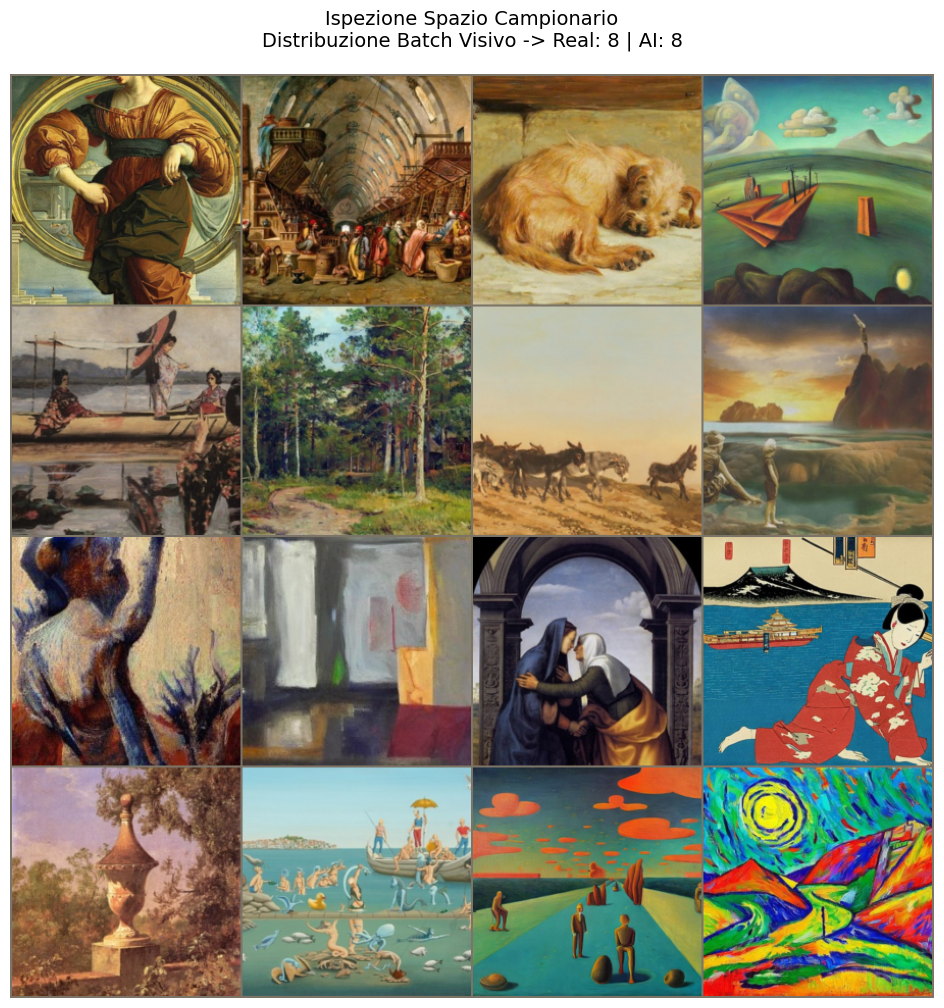


[Analisi del Tensore Campione]
Dimensioni: torch.Size([3, 224, 224])
Valore Minimo (Normalizzato): -1.8953
Valore Massimo (Normalizzato): 2.2535
Media Spaziale: -0.3567


In [ ]:
import matplotlib.pyplot as plt
import torchvision
import numpy as np
import torch

def denormalizza_tensore(tensore, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    """
    Applica l'operatore inverso T_{norm}^{-1} per mappare i valori dal dominio
    standardizzato Z allo spazio colorimetrico originale [0, 1].
    X_{orig} = X_{norm} * \sigma + \mu
    """
    tensore = tensore.clone()
    for t, m, s in zip(tensore, mean, std):
        t.mul_(s).add_(m)
    return torch.clamp(tensore, 0, 1)

def ispeziona_spazio_campionario(dataloader, numero_campioni=16):
    """
    Estrae un sottoinsieme stocastico e ne proietta i tensori su un piano cartesiano
    per la validazione visiva post-cleaning.
    """
    # Estrazione del primo mini-batch X \in R^{B \times 3 \times H \times W}
    batch_tensori, batch_etichette = next(iter(dataloader))

    # Tronchiamo al numero di campioni richiesto
    X_subset = batch_tensori[:numero_campioni]
    Y_subset = batch_etichette[:numero_campioni]

    # Costruzione della griglia visiva
    griglia = torchvision.utils.make_grid(X_subset, nrow=4)
    griglia_denorm = denormalizza_tensore(griglia)

    # Trasposizione degli assi da CHW a HWC per compatibilità con matplotlib
    griglia_np = griglia_denorm.numpy().transpose((1, 2, 0))

    # Calcolo delle frequenze empiriche nel batch
    frequenza_real = torch.sum(Y_subset == 0).item()
    frequenza_ai = torch.sum(Y_subset == 1).item()

    plt.figure(figsize=(12, 12))
    plt.imshow(griglia_np)
    plt.axis('off')

    titolo = (f"Ispezione Spazio Campionario\n"
              f"Distribuzione Batch Visivo -> Real: {frequenza_real} | AI: {frequenza_ai}")
    plt.title(titolo, fontsize=14, pad=20)
    plt.show()

    # Stampa le statistiche di un singolo tensore per validare T_tensor e T_norm
    t_campione = batch_tensori[0]
    print("\n[Analisi del Tensore Campione]")
    print(f"Dimensioni: {t_campione.shape}")
    print(f"Valore Minimo (Normalizzato): {t_campione.min().item():.4f}")
    print(f"Valore Massimo (Normalizzato): {t_campione.max().item():.4f}")
    print(f"Media Spaziale: {t_campione.mean().item():.4f}")

# Esecuzione della diagnostica sul caricatore di addestramento
ispeziona_spazio_campionario(train_loader)

In [ ]:
import json
import random
from pathlib import Path

CACHE_FILE = Path("dataset_cache.json")
DATA_DIR = Path("Real_AI_SD_LD_Dataset")

# Tentativo di recupero variabili se perse dal kernel
if 'dataset_paths' not in locals() or 'dataset_labels' not in locals():
    print("Variabili non trovate in memoria. Ricostruzione in corso...")
    if DATA_DIR.exists():
        estensioni = ['.jpg', '.jpeg', '.png']
        tutti_i_file = []
        for ext in estensioni:
            tutti_i_file.extend(DATA_DIR.rglob(f"*{ext}"))
            tutti_i_file.extend(DATA_DIR.rglob(f"*{ext.upper()}"))

        c_R, c_A = [], []
        for p in tutti_i_file:
            parent = p.parent.name.lower()
            if any(k in parent for k in ['ai', 'fake', 'synthetic', 'sd', 'ld']): c_A.append(str(p))
            elif any(k in parent for k in ['real', 'authentic']): c_R.append(str(p))

        K = min(3000, len(c_R), len(c_A))
        random.seed(42)
        dataset_paths = random.sample(c_R, K) + random.sample(c_A, K)
        dataset_labels = [0]*K + [1]*K
    else:
        print("Errore: Dataset non trovato sul disco.")

# Salvataggio
if 'dataset_paths' in locals():
    print(f"Salvataggio dei metadati in {CACHE_FILE}...")
    with open(CACHE_FILE, 'w') as f:
        json.dump({'paths': dataset_paths, 'labels': dataset_labels}, f)
    print("Operazione completata con successo.")

Salvataggio dei metadati in dataset_cache.json...
Operazione completata con successo.
